# A manual multi-SKU component loop

Build one small inventory workflow from Stockcast components for five synthetic SKUs. You open each demand epoch, review pre-demand state, request eligible orders, then fulfill the complete daily demand vector and record your own snapshots.


## 1. Choose the supported workflow

Stockcast supports two complementary styles. Use `SimulationEngine` for a complete canonical run. Use components when you need control of the loop: your own logic between days, an external forecast refresh, or debugging a single day. Scoring still comes from the engine ledger; Notebook 10 carries this pattern into a daily close with persisted state. This notebook demonstrates that supported component style; it is not an internal workaround.

You run the loop, keep the history table, and track where inputs came from. The history below is your own teaching record, not the engine's validated event ledger.


In [2]:
# Section 1: table tools for the dense SKU-by-period grid.
import pandas as pd


In [3]:
# Shared coordinates for this five-SKU daily scenario.
opening_date = pd.Timestamp('2026-01-05')
period_frequency = 'D'

# Orders take two days to arrive; stock is reviewed every two days.
lead_time = 2
review_period = 2
n_periods = 8


### Declare a complete synthetic SKU-by-period grid

The scenario has five named synthetic items, eight daily periods, observed opening stock, and one direct cumulative target per item. The 40 rows are a complete teaching grid, not a bundled or production full dataset. Stockcast does not infer missing demand, opening stock, or targets.


In [4]:
# Values are explicit synthetic scenario inputs, not observations or forecasts.
skus = ['tea_250g', 'coffee_250g', 'pasta_500g', 'cereal_400g', 'soup_400g']
opening_stock = pd.DataFrame({
    'unique_id': skus,
    'observed_on_hand': [20.0, 22.0, 18.0, 19.0, 16.0],
})
demand_values = {
    'tea_250g': [6.0, 8.0, 5.0, 7.0, 6.0, 4.0, 7.0, 5.0],
    'coffee_250g': [4.0, 5.0, 6.0, 5.0, 7.0, 6.0, 4.0, 5.0],
    'pasta_500g': [5.0, 4.0, 6.0, 5.0, 4.0, 6.0, 5.0, 4.0],
    'cereal_400g': [3.0, 5.0, 4.0, 6.0, 5.0, 3.0, 4.0, 6.0],
    'soup_400g': [2.0, 3.0, 4.0, 3.0, 5.0, 4.0, 3.0, 2.0],
}


In [5]:
# A transparent wide-to-long reshape makes the full dense input visible.
demand_wide = pd.DataFrame(
    demand_values,
    index=pd.date_range(opening_date + pd.Timedelta(days=1), periods=n_periods, freq=period_frequency),
).rename_axis('date').reset_index()
demand = demand_wide.melt(id_vars='date', var_name='unique_id', value_name='y')
demand['period'] = demand.groupby('unique_id').cumcount()
demand = demand[['unique_id', 'period', 'date', 'y']].sort_values(['period', 'unique_id']).reset_index(drop=True)

# One direct cumulative target per SKU for the four-day protection horizon.
target = pd.DataFrame({
    'unique_id': skus,
    'protection_target': [30.0, 31.0, 27.0, 28.0, 22.0],
    'target_end_date': [opening_date + pd.Timedelta(days=lead_time + review_period)] * len(skus),
})
target


,unique_id,protection_target,target_end_date
0,tea_250g,30.0,2026-01-09
1,coffee_250g,31.0,2026-01-09
2,pasta_500g,27.0,2026-01-09
3,cereal_400g,28.0,2026-01-09
4,soup_400g,22.0,2026-01-09


In [6]:
# Opening stock is a declared scenario input, not an estimate from demand.
opening_stock


,unique_id,observed_on_hand
0,tea_250g,20.0
1,coffee_250g,22.0
2,pasta_500g,18.0
3,cereal_400g,19.0
4,soup_400g,16.0


In [7]:
# Externally calculated four-day cumulative targets, one per SKU.
target


,unique_id,protection_target,target_end_date
0,tea_250g,30.0,2026-01-09
1,coffee_250g,31.0,2026-01-09
2,pasta_500g,27.0,2026-01-09
3,cereal_400g,28.0,2026-01-09
4,soup_400g,22.0,2026-01-09


In [8]:
# The 40 rows are a complete teaching grid: five SKUs over eight daily periods.
assert len(demand) == len(skus) * n_periods
assert demand.groupby('period')['unique_id'].nunique().eq(len(skus)).all()
assert demand[['unique_id', 'period']].duplicated().sum() == 0
assert demand['date'].min() == opening_date + pd.Timedelta(days=1)

demand.head(15)


,unique_id,period,date,y
0,cereal_400g,0,2026-01-06,3.0
1,coffee_250g,0,2026-01-06,4.0
2,pasta_500g,0,2026-01-06,5.0
3,soup_400g,0,2026-01-06,2.0
4,tea_250g,0,2026-01-06,6.0
5,cereal_400g,1,2026-01-07,5.0
6,coffee_250g,1,2026-01-07,5.0
7,pasta_500g,1,2026-01-07,4.0
8,soup_400g,1,2026-01-07,3.0
9,tea_250g,1,2026-01-07,8.0


### See every declared demand series

This two-row, four-column grid shows each SKU's complete daily demand series before inventory decisions. A sixth panel gives the portfolio total; every panel uses lines and markers only, with no area shading.


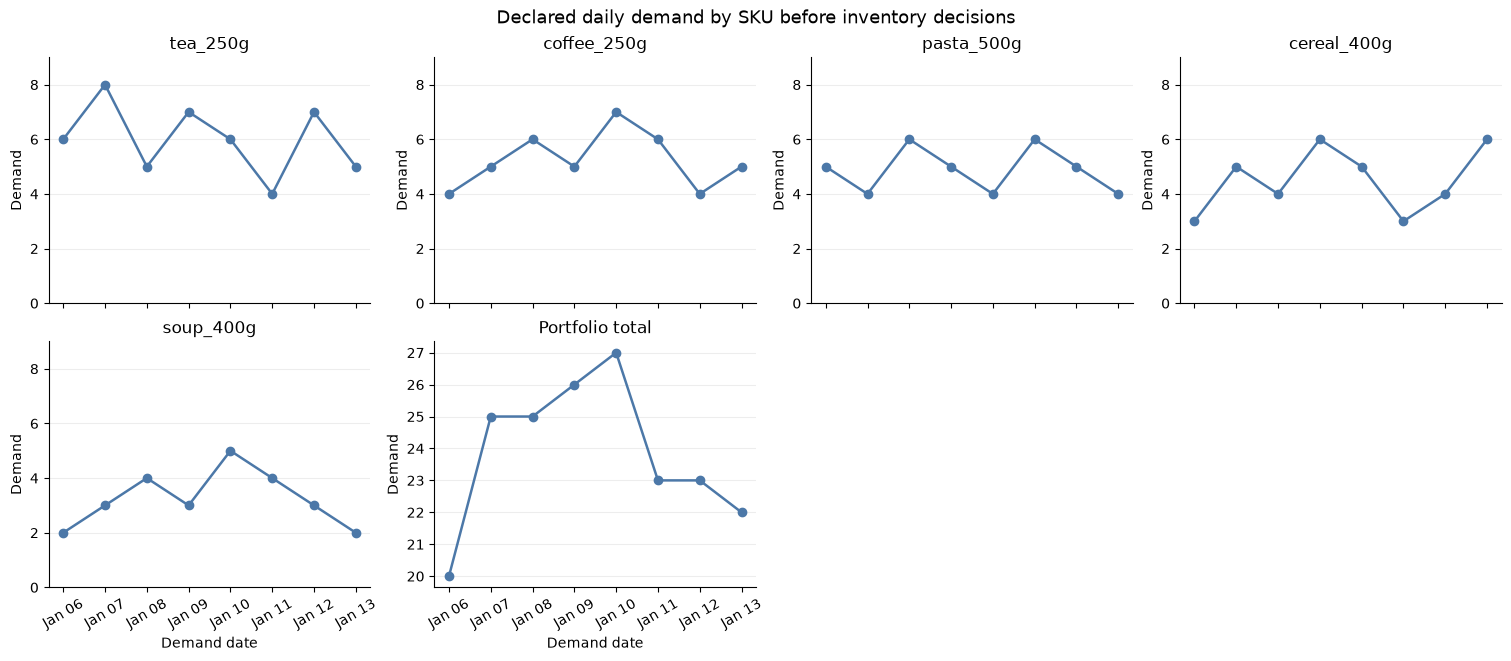

In [9]:
# Section 1 plot: per-SKU demand series plus the portfolio total.
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

portfolio_demand = demand.groupby('date', as_index=False)['y'].sum()
demand_series = [(sku, demand.loc[demand['unique_id'].eq(sku), ['date', 'y']]) for sku in skus]
demand_series.append(('Portfolio total', portfolio_demand))
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5), sharex=True, layout='constrained')
for axis, (label, series) in zip(axes.flat, demand_series):
    axis.plot(series['date'], series['y'], color='#4C78A8', marker='o', linewidth=1.8)
    axis.set(title=label, ylabel='Demand')
    if label != 'Portfolio total':
        axis.set_ylim(0, demand['y'].max() + 1)
    axis.grid(axis='y', alpha=0.22)
    axis.spines[['top', 'right']].set_visible(False)
for axis in axes.flat[len(demand_series):]:
    axis.set_visible(False)
for axis in axes[1]:
    axis.set_xlabel('Demand date')
    axis.xaxis.set_major_locator(mdates.DayLocator())
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    axis.tick_params(axis='x', labelrotation=30)
fig.suptitle('Declared daily demand by SKU before inventory decisions', fontsize=13)
plt.show()


## 2. Fit one explicit policy across the SKU set

`OrderUpToPolicy` uses a direct four-day cumulative target for each SKU: two lead-time days plus two review-cycle days. The targets are provided, dated, probability-labelled, and explicitly external; this notebook does not fit a forecast or create uncertainty heuristics.


In [10]:
# Section 2: order-up-to policy shared across the five SKUs.
from stockcast import OrderUpToPolicy

policy = OrderUpToPolicy(
    lead_time=lead_time,  # 2-day delivery delay; order enters pipeline, not on-hand.
    review_period=review_period,  # Review every 2 days; only those periods may order.
    service_level=0.95,  # Declared 95% protection; must match target_probability below.
    allow_backorders=False,  # Lost sales; matches the opening state, unmet demand is lost.
).fit(
    target,  # One externally calculated cumulative target row per SKU.
    target_column='protection_target',  # S value column for the 4-day horizon.
    target_probability=0.95,  # Probability the target represents; fail-closed match to service_level.
    protection_horizon=lead_time + review_period,  # H = 2 + 2 = 4 days of demand to cover.
    target_source='external_direct',  # Asserts S was computed outside Stockcast; no aggregation.
    forecast_origin=opening_date,  # Info date of the opening state; anchors end-date check.
    forecast_frequency=period_frequency,  # Daily steps; must match demand and state frequency.
    target_end_date_column='target_end_date',  # Must equal origin + H; validated.
)
print('Fitted per-SKU targets')
print(policy.get_target_levels().to_string(index=False))
print('\nShared target metadata')
print(pd.DataFrame([policy.get_target_metadata()]).to_string(index=False))


Fitted per-SKU targets
  unique_id  target_level
   tea_250g          30.0
coffee_250g          31.0
 pasta_500g          27.0
cereal_400g          28.0
  soup_400g          22.0

Shared target metadata
                 representation  target_probability  protection_horizon   target_source     forecast_origin forecast_frequency     target_end_date
direct_protection_period_target                0.95                   4 external_direct 2026-01-05T00:00:00                  D 2026-01-09T00:00:00


### Set up the inventory

The observed opening state has zero backlog and an empty two-slot pipeline for each SKU. Each component call returns a new state snapshot, which the loop carries forward.


In [11]:
# Section 2 continued: inventory holding on-hand, pipeline, and backlog.
from stockcast import InventoryStateDataFrame

# This is your working object; every component call below returns a new snapshot.
manual_state = InventoryStateDataFrame(
    skus, max_lead_time=lead_time, allow_backorders=False
).initialize_from_observed(
    opening_stock, on_hand_column='observed_on_hand', start_date=opening_date
)
manual_state


InventoryStateDataFrame(n_skus=5, total_on_hand=95, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

In [12]:
print('Explicit opening state')
print(manual_state.get_dataframe()[['unique_id', 'on_hand', 'backorders', 'in_transit', 'period', 'date']].to_string(index=False))


Explicit opening state
  unique_id  on_hand  backorders in_transit  period       date
   tea_250g     20.0         0.0 [0.0, 0.0]     0.0 2026-01-05
coffee_250g     22.0         0.0 [0.0, 0.0]     0.0 2026-01-05
 pasta_500g     18.0         0.0 [0.0, 0.0]     0.0 2026-01-05
cereal_400g     19.0         0.0 [0.0, 0.0]     0.0 2026-01-05
  soup_400g     16.0         0.0 [0.0, 0.0]     0.0 2026-01-05


## Execute the component loop

Open the epoch with `advance_period`, consult the schedule, predict and apply
orders, then call `fulfill_demand`. This is the same sequence as the engine.
The caller owns recording and validation in this manual example.


In [13]:
# Section 3: one pass over the 8 days. Each day repeats the same 4 steps:
#   1. open the epoch and receive due stock,
#   2. check whether today is an order day,
#   3. if so, ask the policy and park the order in the pipeline,
#   4. fulfill demand and write one history row per SKU.
from stockcast.utils import update_inventory_with_orders

history_rows = []
order_rows = []

for demand_period in range(n_periods):
    # One complete demand vector: all five SKUs sharing a single date.
    daily_demand = demand.loc[demand['period'].eq(demand_period), ['unique_id', 'date', 'y']]

    # Step 1: advance and receive; the policy has not seen current demand.
    manual_state = manual_state.advance_period(
        period_frequency=period_frequency, is_review_period=policy.schedule.should_decide(demand_period)
    )
    state_df = manual_state.get_dataframe()
    # All five rows share one clock, so the first row speaks for the day.
    current_period = int(state_df['period'].iloc[0])
    on_hand_before_order = state_df.set_index('unique_id')['on_hand']

    # Steps 2-3: on order days only, request stock for the pipeline.
    # Ordering never touches today's shelf stock; it arrives 2 days later.
    if bool(state_df['is_review_period'].iloc[0]):
        decision = policy.predict(manual_state, current_period=current_period)
        order_rows.extend(decision.get_dataframe().to_dict('records'))
        manual_state = update_inventory_with_orders(manual_state, decision, policy=policy)

    # Positive-lead-time placement preserves stock before fulfillment.
    assert manual_state.data.set_index('unique_id').on_hand.equals(on_hand_before_order)
    manual_state = manual_state.fulfill_demand(daily_demand)
    on_hand_after_demand = manual_state.data.set_index('unique_id').on_hand

    # Step 4: snapshot the day. inventory_position() adds the latest_* flow
    # fields (what just happened today) next to the stock levels.
    state_view = manual_state.inventory_position()[[
        'unique_id', 'period',  # who and when; one row per SKU per day
        'latest_received',  # arrived today from an order placed 2 days ago
        'latest_order',  # ordered today (0 on non-order days)
        'latest_fulfilled',  # demand served today
        'latest_shortage',  # demand lost today (0 here; lost-sales mode)
        'on_hand',  # shelf stock at end of day
        'backorders',  # always 0 here; kept so the shape matches the engine
        'total_in_transit',  # pipeline: ordered but not yet arrived
        'inventory_position',  # on-hand plus pipeline minus backlog
        'is_review_period',  # whether today was an order day
    ]].copy()  # copy so later edits never touch the live state
    # JOIN the demand vector with the state view. Each SKU appears exactly
    # once on each side, and validate='one_to_one' fails loudly otherwise.
    snapshot = daily_demand.merge(state_view, on='unique_id', validate='one_to_one').rename(columns={
        'y': 'demand',  # input convention: demand arrives in a column named y
        'latest_received': 'received',  # plain history names from here on
        'latest_order': 'ordered',
        'latest_fulfilled': 'fulfilled',
        'latest_shortage': 'shortage',
        'total_in_transit': 'pipeline',  # friendlier name for the same number
    })
    # Retain the post-demand shelf count for the independent timing comparison.
    snapshot['on_hand_after_demand'] = snapshot['unique_id'].map(on_hand_after_demand)
    history_rows.extend(snapshot.to_dict('records'))

manual_history = pd.DataFrame(history_rows).sort_values(['period', 'unique_id']).reset_index(drop=True)
manual_orders = pd.DataFrame(order_rows).sort_values(['order_period', 'unique_id']).reset_index(drop=True)


### Inspect snapshots and requests

Each row is one SKU after one daily transition. The rows show the full state shape used by a multi-SKU loop, kept separate from the engine's event ledger.


In [14]:
history_columns = [
    'period', 'date', 'unique_id', 'demand', 'received', 'ordered', 'on_hand',
    'pipeline', 'inventory_position', 'is_review_period',
]
print('State snapshots (first 15 of 40 rows)')
print(manual_history[history_columns].head(15).round(2).to_string(index=False))


State snapshots (first 15 of 40 rows)
 period       date   unique_id  demand  received  ordered  on_hand  pipeline  inventory_position  is_review_period
    1.0 2026-01-06 cereal_400g     3.0       0.0      9.0     16.0       9.0                25.0              True
    1.0 2026-01-06 coffee_250g     4.0       0.0      9.0     18.0       9.0                27.0              True
    1.0 2026-01-06  pasta_500g     5.0       0.0      9.0     13.0       9.0                22.0              True
    1.0 2026-01-06   soup_400g     2.0       0.0      6.0     14.0       6.0                20.0              True
    1.0 2026-01-06    tea_250g     6.0       0.0     10.0     14.0      10.0                24.0              True
    2.0 2026-01-07 cereal_400g     5.0       0.0      0.0     11.0       9.0                20.0             False
    2.0 2026-01-07 coffee_250g     5.0       0.0      0.0     13.0       9.0                22.0             False
    2.0 2026-01-07  pasta_500g     4.0    

/tmp/ipykernel_1167757/250061028.py:6: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(manual_history[history_columns].head(15).round(2).to_string(index=False))


In [15]:
print('Policy order requests (first 10 rows)')
print(manual_orders[['unique_id', 'order_period', 'expected_delivery_period', 'order_quantity']].head(10).round(2).to_string(index=False))

print('\nPositive order requests by SKU')
print(manual_orders.loc[manual_orders['order_quantity'] > 0, 'unique_id'].value_counts().to_string())


Policy order requests (first 10 rows)
  unique_id  order_period  expected_delivery_period  order_quantity
cereal_400g             1                         3             9.0
coffee_250g             1                         3             9.0
 pasta_500g             1                         3             9.0
  soup_400g             1                         3             6.0
   tea_250g             1                         3            10.0
cereal_400g             3                         5             8.0
coffee_250g             3                         5             9.0
 pasta_500g             3                         5             9.0
  soup_400g             3                         5             5.0
   tea_250g             3                         5            14.0

Positive order requests by SKU
unique_id
cereal_400g    4
coffee_250g    4
pasta_500g     4
soup_400g      4
tea_250g       4


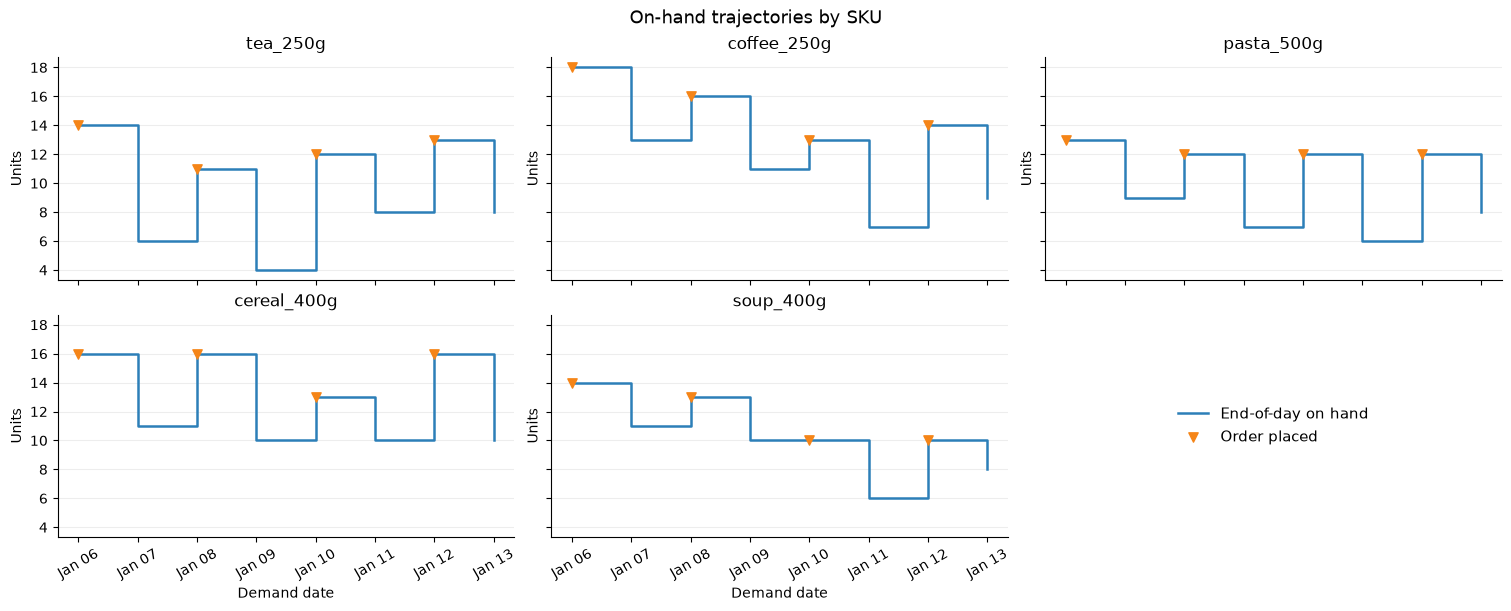

In [16]:
# One idea: on-hand sawtooth per SKU; the engine comparison comes later.
fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True, sharey=True, layout='constrained')
for axis, sku in zip(axes.flat, skus):
    series = manual_history.loc[manual_history['unique_id'].eq(sku)].sort_values('period')
    axis.step(series['date'], series['on_hand'], where='post', color='#2C7FB8', linewidth=1.8)
    sku_orders = series.loc[series['ordered'] > 0]
    axis.scatter(sku_orders['date'], sku_orders['on_hand'], marker='v', s=45, color='#F58518', zorder=4)
    axis.set(title=sku, ylabel='Units')
    axis.grid(axis='y', alpha=0.22)
    axis.spines[['top', 'right']].set_visible(False)
# The sixth slot holds the shared key instead of overlapping the title.
legend_ax = axes.flat[-1]
legend_ax.axis('off')
on_hand_key, = legend_ax.plot([], [], color='#2C7FB8', linewidth=1.8, label='End-of-day on hand')
order_key = legend_ax.scatter([], [], marker='v', s=45, color='#F58518', label='Order placed')
legend_ax.legend(handles=[on_hand_key, order_key], loc='center', frameon=False, fontsize=11)
for axis in (axes[1][0], axes[1][1]):
    axis.set_xlabel('Demand date')
    axis.xaxis.set_major_locator(mdates.DayLocator())
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    axis.tick_params(axis='x', labelrotation=30)
fig.suptitle('On-hand trajectories by SKU', fontsize=13)
plt.show()


## 4. Summarize the history

These totals describe the snapshots; they are not evaluator outputs or a performance claim. They make each item's demand, orders, ending stock, and pipeline visible before the engine comparison.


In [17]:
summary_by_sku = manual_history.groupby('unique_id', as_index=False).agg(
    total_demand=('demand', 'sum'),
    total_received=('received', 'sum'),
    total_ordered=('ordered', 'sum'),
    total_shortage=('shortage', 'sum'),
    ending_on_hand=('on_hand', 'last'),
    ending_pipeline=('pipeline', 'last'),
).sort_values('unique_id')
print(summary_by_sku.round(2).to_string(index=False))
assert summary_by_sku['total_shortage'].eq(0.0).all()


  unique_id  total_demand  total_received  total_ordered  total_shortage  ending_on_hand  ending_pipeline
cereal_400g          36.0            27.0           35.0             0.0            10.0              8.0
coffee_250g          42.0            29.0           42.0             0.0             9.0             13.0
 pasta_500g          39.0            29.0           39.0             0.0             8.0             10.0
  soup_400g          26.0            18.0           27.0             0.0             8.0              9.0
   tea_250g          48.0            36.0           46.0             0.0             8.0             10.0


### Keep the portfolio totals inspectable

This compact table sums the five snapshots at each date. It remains descriptive evidence only; the canonical aggregate visual follows the equivalent engine run.


In [18]:
portfolio_history = manual_history.groupby(['period', 'date'], as_index=False).agg(
    demand=('demand', 'sum'), fulfilled=('fulfilled', 'sum'), shortage=('shortage', 'sum'),
    received=('received', 'sum'), ordered=('ordered', 'sum'),
    on_hand=('on_hand', 'sum'), pipeline=('pipeline', 'sum'),
    inventory_position=('inventory_position', 'sum'),
)
print('Portfolio totals by daily snapshot')
print(portfolio_history.round(2).to_string(index=False))


Portfolio totals by daily snapshot
 period       date  demand  fulfilled  shortage  received  ordered  on_hand  pipeline  inventory_position
    1.0 2026-01-06    20.0       20.0       0.0       0.0     43.0     75.0      43.0               118.0
    2.0 2026-01-07    25.0       25.0       0.0       0.0      0.0     50.0      43.0                93.0
    3.0 2026-01-08    25.0       25.0       0.0      43.0     45.0     68.0      45.0               113.0
    4.0 2026-01-09    26.0       26.0       0.0       0.0      0.0     42.0      45.0                87.0
    5.0 2026-01-10    27.0       27.0       0.0      45.0     51.0     60.0      51.0               111.0
    6.0 2026-01-11    23.0       23.0       0.0       0.0      0.0     37.0      51.0                88.0
    7.0 2026-01-12    23.0       23.0       0.0      51.0     50.0     65.0      50.0               115.0
    8.0 2026-01-13    22.0       22.0       0.0       0.0      0.0     43.0      50.0                93.0


/tmp/ipykernel_1167757/869878444.py:8: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(portfolio_history.round(2).to_string(index=False))


### Keep the per-SKU end state compact

The terminal-state table remains useful for inspection, but it does not try to visualize in-transit timing. The engine-owned aggregate visual below makes order, receipt, and unreceived-order timing explicit.


In [19]:
manual_terminal_view = manual_history.sort_values(['unique_id', 'period']).groupby('unique_id', as_index=False).tail(1)
print(manual_terminal_view[[
    'unique_id', 'on_hand', 'pipeline', 'inventory_position', 'backorders', 'date'
]].round(2).to_string(index=False))


  unique_id  on_hand  pipeline  inventory_position  backorders       date
cereal_400g     10.0       8.0                18.0         0.0 2026-01-13
coffee_250g      9.0      13.0                22.0         0.0 2026-01-13
 pasta_500g      8.0      10.0                18.0         0.0 2026-01-13
  soup_400g      8.0       9.0                17.0         0.0 2026-01-13
   tea_250g      8.0      10.0                18.0         0.0 2026-01-13


/tmp/ipykernel_1167757/2105777979.py:4: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ]].round(2).to_string(index=False))


### Make the component timing executable

Every positive order must have expected delivery exactly two periods later. For arrivals inside the eight-period horizon, the matching receipt in the history table must equal the earlier order quantity. The saved pre-order on-hand value verifies that placement itself did not alter physical stock.


In [20]:
positive_orders = manual_orders.loc[manual_orders['order_quantity'].gt(0)].copy()
print('Positive SKU orders (first 10)')
print(positive_orders[['unique_id', 'order_period', 'expected_delivery_period', 'order_quantity']].head(10).round(2).to_string(index=False))

assert (positive_orders['expected_delivery_period'] == positive_orders['order_period'] + lead_time).all()
assert (positive_orders['expected_delivery_period'] > positive_orders['order_period']).all()

review_snapshots = manual_history.loc[manual_history['ordered'].gt(0)]
assert (review_snapshots['on_hand'] == review_snapshots['on_hand_after_demand']).all()

arrivals_in_horizon = positive_orders.loc[positive_orders['expected_delivery_period'].le(n_periods)]
arrival_snapshots = manual_history.merge(
    arrivals_in_horizon[['unique_id', 'expected_delivery_period', 'order_quantity']],
    left_on=['unique_id', 'period'], right_on=['unique_id', 'expected_delivery_period'],
    validate='one_to_one',
)
assert (arrival_snapshots['received'] == arrival_snapshots['order_quantity']).all()
print(f'\nValidated {len(positive_orders)} positive SKU orders and {len(arrivals_in_horizon)} in-horizon receipts.')


Positive SKU orders (first 10)
  unique_id  order_period  expected_delivery_period  order_quantity
cereal_400g             1                         3             9.0
coffee_250g             1                         3             9.0
 pasta_500g             1                         3             9.0
  soup_400g             1                         3             6.0
   tea_250g             1                         3            10.0
cereal_400g             3                         5             8.0
coffee_250g             3                         5             9.0
 pasta_500g             3                         5             9.0
  soup_400g             3                         5             5.0
   tea_250g             3                         5            14.0

Validated 20 positive SKU orders and 15 in-horizon receipts.


## 5. Compare with the equivalent engine run

The component loop is supported, but it does not recreate complete-run preflight, canonical events, callback phases, policy-schedule validation, constraints/audit orchestration, evaluator-ready outputs, or a run manifest. This engine case has no constraints or callbacks and no opening decision, so its physical transitions match the loop above.


In [21]:
# Section 5: equivalent engine run for canonical events and metrics.
from stockcast import SimulationEngine

engine_opening_state = InventoryStateDataFrame(
    skus, max_lead_time=lead_time, allow_backorders=False
).initialize_from_observed(
    opening_stock, on_hand_column='observed_on_hand', start_date=opening_date
)
engine_result = SimulationEngine().run(
    policy=policy,  # Same fitted (R,S) policy; engine deep-copies it.
    demand_source=demand,  # Same complete 40-row grid; consumed in every window.
    inventory=engine_opening_state,  # Fresh explicit opening state; the loop state above stays unchanged.
    n_periods=n_periods,  # All 8 demand periods; must equal warmup + scoring + settlement.
    period_frequency=period_frequency,  # 'D': one engine step per demand date, forward only.
    initial_decision='none',  # First decision is before demand period 0.
    warmup_periods=0,  # No warm-up slice; every period scores in this comparison.
    scoring_periods=n_periods,  # All 8 periods feed summary() and evaluation below.
    settlement_periods=0,  # No tail slice here; settlement ordering flag is then inert.
    order_during_settlement=False,  # Explicit even with zero settlement periods.
    demand_source_name='declared_five_sku_component_loop',  # Provenance label kept in the manifest.
    random_seed=None,  # Fully declared grid, no random generator involved.
)


In [22]:
# This is the engine's copy; `manual_state` above is unchanged.
engine_result.inventory


InventoryStateDataFrame(n_skus=5, total_on_hand=43, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

### Read aggregate operations from canonical events

This figure uses validated engine event rows, not the history snapshots. **Unreceived orders at end of day** is the quantity already accepted as an order but not yet physical stock (often called the pipeline). It rises when orders are placed and falls when receipts arrive; the separate order and receipt panels make that timing visible.


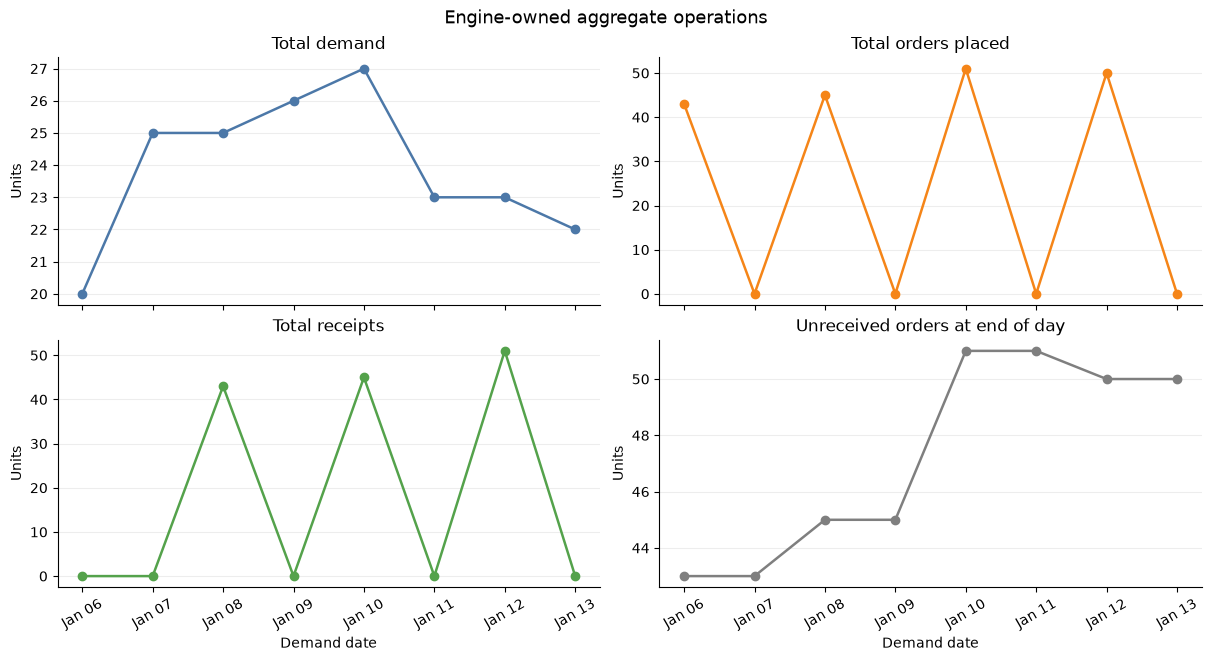

In [23]:
engine_period_events = engine_result.to_event_frame(window='scoring')
engine_period_events = engine_period_events.loc[
    engine_period_events['event_type'].eq('period')
].copy()
engine_portfolio = engine_period_events.groupby(['period', 'date'], as_index=False).agg(
    demand=('demand', 'sum'),
    orders_placed=('order_quantity', 'sum'),
    receipts=('received_units', 'sum'),
    unreceived_orders_end=('on_order_end', 'sum'),
)
operation_panels = [
    ('Total demand', 'demand', '#4C78A8'),
    ('Total orders placed', 'orders_placed', '#F58518'),
    ('Total receipts', 'receipts', '#54A24B'),
    ('Unreceived orders at end of day', 'unreceived_orders_end', '#7F7F7F'),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 6.5), sharex=True, layout='constrained')
for axis, (title, column, color) in zip(axes.flat, operation_panels):
    axis.plot(engine_portfolio['date'], engine_portfolio[column],
              color=color, marker='o', linewidth=1.8)
    axis.set(title=title, ylabel='Units')
    axis.grid(axis='y', alpha=0.22)
    axis.spines[['top', 'right']].set_visible(False)
for axis in axes[1]:
    axis.set_xlabel('Demand date')
    axis.xaxis.set_major_locator(mdates.DayLocator())
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    axis.tick_params(axis='x', labelrotation=30)
fig.suptitle('Engine-owned aggregate operations', fontsize=13)
plt.show()


### Use the engine ledger for canonical metrics

Unlike the history snapshots, the engine result contains validated event rows. These per-SKU and pooled metrics therefore come from `InventoryEvaluator` with an explicit scoring window and grouping. Zero shortages in this deliberately stocked scenario make fill rate 1.0 for every item; the chart is descriptive, not a policy comparison.


In [24]:
# Section 5 continued: canonical metrics from validated events, not history snapshots.
from stockcast.evaluation import InventoryEvaluator, avg_on_hand, fill_rate, order_units

canonical_per_sku = InventoryEvaluator().fit(
    simulation_result=engine_result, window='scoring'
).evaluate(
    metrics=[fill_rate, avg_on_hand, order_units], groupby=['unique_id']
)
canonical_pooled = InventoryEvaluator().fit(
    simulation_result=engine_result, window='scoring'
).evaluate(
    metrics=[fill_rate, avg_on_hand, order_units], groupby=[]
)
print('Canonical per-SKU metrics from engine events')
print(canonical_per_sku.round(3).to_string(index=False))
print('\nCanonical pooled metrics from engine events')
print(canonical_pooled.round(3).to_string(index=False))


Canonical per-SKU metrics from engine events
  unique_id  fill_rate  avg_on_hand  order_units
   tea_250g        1.0        9.500         46.0
coffee_250g        1.0       12.625         42.0
 pasta_500g        1.0        9.875         39.0
cereal_400g        1.0       12.750         35.0
  soup_400g        1.0       10.250         27.0

Canonical pooled metrics from engine events
 fill_rate  avg_on_hand  order_units
       1.0         11.0        189.0


### Compare canonical item-level summary statistics

Separate panels keep the rate and unit measures on honest scales: service is a rate, while average stock and ordered units are quantities.


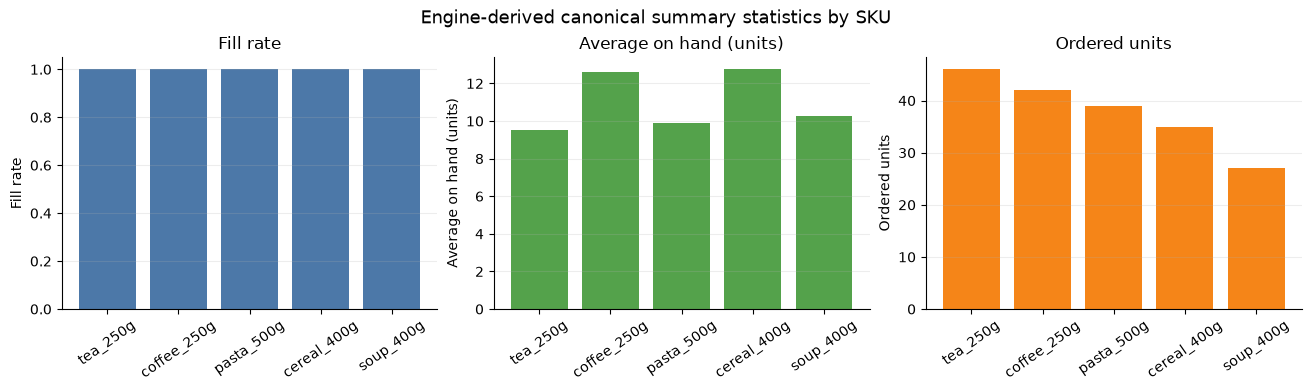

In [25]:
metric_panels = [
    ('fill_rate', 'Fill rate', '#4C78A8'),
    ('avg_on_hand', 'Average on hand (units)', '#54A24B'),
    ('order_units', 'Ordered units', '#F58518'),
]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), layout='constrained')
for axis, (column, label, color) in zip(axes, metric_panels):
    axis.bar(canonical_per_sku['unique_id'], canonical_per_sku[column], color=color)
    axis.set(title=label, ylabel=label)
    axis.tick_params(axis='x', rotation=35)
    axis.grid(axis='y', alpha=0.22)
    axis.spines[['top', 'right']].set_visible(False)
fig.suptitle('Engine-derived canonical summary statistics by SKU', fontsize=13)
plt.show()


### Compare terminal state, not artifact ownership

Under these matched conditions, every SKU ends with the same physical and pipeline state in both paths. This equality does not turn history snapshots into engine events or a manifest; it confirms the component transitions only.


In [26]:
terminal_fields = ['unique_id', 'on_hand', 'backorders', 'total_in_transit', 'inventory_position', 'period', 'date']
manual_terminal = manual_state.inventory_position()[terminal_fields].sort_values('unique_id').reset_index(drop=True)
engine_terminal = engine_result.inventory.inventory_position()[terminal_fields].sort_values('unique_id').reset_index(drop=True)
terminal_comparison = manual_terminal.merge(
    engine_terminal, on='unique_id', suffixes=('_manual_loop', '_engine')
)
print(terminal_comparison.to_string(index=False))

for field in terminal_fields[1:]:
    assert manual_terminal[field].equals(engine_terminal[field])
assert engine_result.to_event_frame().shape[0] == len(demand)
print('\nAll five terminal states match the equivalent engine run.')


  unique_id  on_hand_manual_loop  backorders_manual_loop  total_in_transit_manual_loop  inventory_position_manual_loop  period_manual_loop date_manual_loop  on_hand_engine  backorders_engine  total_in_transit_engine  inventory_position_engine  period_engine date_engine
cereal_400g                 10.0                     0.0                           8.0                            18.0                 8.0       2026-01-13            10.0                0.0                      8.0                       18.0            8.0  2026-01-13
coffee_250g                  9.0                     0.0                          13.0                            22.0                 8.0       2026-01-13             9.0                0.0                     13.0                       22.0            8.0  2026-01-13
 pasta_500g                  8.0                     0.0                          10.0                            18.0                 8.0       2026-01-13             8.0                0.0

## Takeaway

A manual loop is supported for deliberate custom orchestration across complete multi-SKU demand vectors. You keep your own notes and input records. Choose `SimulationEngine` when the work also needs complete preflight, canonical accounting events, callback/constraint audits, evaluator-ready results, and a run manifest.
